# 11 - CCSM4 alignment and the two prior distributions

Groundwork for transfer learning of the generative prior. The LOVECLIM record is 804
states, a small corpus for a convolutional score model, so the intended fix is to
pre-train the denoiser on the constant-CO2 CCSM4 run of Vettoretti et al. 2022 and
fine-tune on LOVECLIM. Two things have to hold first: the CCSM4 fields must be genuinely
comparable to the LOVECLIM ones, and the two state distributions have to be understood
well enough to know what transfer is being asked to bridge.

This notebook does both. It aligns the 210 ppm run onto the prior grid, checks that
alignment, and then compares the two distributions through the leading principal
components of the joint `(mtco, mtwa)` state.

No training here, and nothing written under `outputs/da/`.

In [1]:
%load_ext autoreload
%autoreload 2

import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.equilibrium import (
    assign_hemispheric_channels, cube_on_grid, load_equilibrium_run, seasonal_means,
)
from paleoreco.data.regrid import conservative_regrid
from paleoreco.eval import (
    orient_pcs, pc_pattern_correlation, pca_scores,
    plot_pc_score_distributions, plot_pc_score_qq,
)

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
FIG = Path("../outputs/figures/11_generative_prior_tl")
FIG.mkdir(parents=True, exist_ok=True)

CCSM4_RUN = f"{DATA}/cesmi6gat31rblc210_surfacetemp.npz"
N_COMPONENTS = 4

## The channel definition

The prior's `mtco` and `mtwa` are not the coldest and warmest month. They are the two
solstitial 3-month means assigned by hemisphere: north of the equator (and on it) the
cold channel is the boreal-winter season and the warm channel the boreal-summer one,
south of it they swap. That is a different statistic from a month extreme, colder in
`mtco` and warmer in `mtwa`, and with a larger per-cell anomaly variance.

Matching it is what makes the two models' channels the same quantity, so the rule is
asserted against the prior's own seasonal columns before it is applied to CCSM4.

In [2]:
cols = ["lat", "st_1", "st_2", "st_3", "st_4", "mtco", "mtwa"]
p = pd.read_csv(f"{DATA}/Prior.csv", usecols=cols)
st = p[["st_1", "st_2", "st_3", "st_4"]].to_numpy()
north = p["lat"].to_numpy() >= 0.0

# st_1 behaves as the boreal-winter season and st_3 as the boreal-summer one.
cold_rule = np.where(north, st[:, 0], st[:, 2])
warm_rule = np.where(north, st[:, 2], st[:, 0])
match_cold = float(np.isclose(p["mtco"], cold_rule).mean())
match_warm = float(np.isclose(p["mtwa"], warm_rule).mean())

print(f"rows {len(p):,}")
print(f"mtco == hemispheric solstitial season: {match_cold:.6f}")
print(f"mtwa == hemispheric solstitial season: {match_warm:.6f}")
assert match_cold == 1.0 and match_warm == 1.0, \
    "the prior's channel rule is not what the CCSM4 alignment assumes"

# Two consequences of the rule, both of which carry over to the aligned CCSM4 cube.
print(f"assigned cold season is not the coldest of the four: "
      f"{float((~np.isclose(p['mtco'], st.min(1))).mean()):.4f} of cells")
print(f"mtco exceeds mtwa:                                  "
      f"{float((p['mtco'] > p['mtwa']).mean()):.4f} of cells")
del p, st

rows 1,646,592
mtco == hemispheric solstitial season: 1.000000
mtwa == hemispheric solstitial season: 1.000000
assigned cold season is not the coldest of the four: 0.2631 of cells
mtco exceeds mtwa:                                  0.0455 of cells


## Grid conventions

CCSM4 is 48 x 96 on Gaussian latitudes with unequal spacing and longitudes running 0 to
356.25. The prior is 32 x 64, equiangular at 5.625 degrees, latitudes -84.375 to 90.0 and
longitudes -174.375 to 180. The remap resolves the longitude convention from the
coordinates themselves, so only the latitude reading is a choice.

Those prior coordinates are read here as **cell centres**, which is what the rest of the
pipeline assumes. It is worth being explicit that this reading does not tile the sphere:
the northernmost row then spans 87.1875 to 92.8125 and overhangs the pole, and the band
from -90 to -87.1875 belongs to no cell. Both show up below as a small residual in the
conservation check. The alternative reading, that the coordinates label northern and
eastern cell edges, would shift every cell by half a cell; deciding between them needs the
provenance of the prior file rather than more arithmetic.

In [3]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
lov, lats, lons = P["cube"].astype(np.float64), P["lats"], P["lons"]
run = load_equilibrium_run(CCSM4_RUN)

print(f"LOVECLIM  {lov.shape}  lat {lats[0]:8.3f}..{lats[-1]:7.3f}  "
      f"lon {lons[0]:9.3f}..{lons[-1]:7.3f}")
print(f"CCSM4     {tuple(run['TREFHT'].shape)}  lat {run['lat'][0]:8.3f}..{run['lat'][-1]:7.3f}  "
      f"lon {run['lon'][0]:9.3f}..{run['lon'][-1]:7.3f}   (month, decade, lat, lon)")
print(f"CCSM4 latitude spacing {np.diff(run['lat']).min():.3f} to "
      f"{np.diff(run['lat']).max():.3f} degrees, so Gaussian rather than equiangular")
print(f"CCSM4 run {run['run']} at {run['co2_ppmv']} ppmv, {run['TREFHT'].shape[1]} decades")

LOVECLIM  (804, 2, 32, 64)  lat  -84.375.. 90.000  lon  -174.375..180.000
CCSM4     (12, 788, 48, 96)  lat  -87.159.. 87.159  lon     0.000..356.250   (month, decade, lat, lon)
CCSM4 latitude spacing 3.680 to 3.711 degrees, so Gaussian rather than equiangular
CCSM4 run cesmi6gat31rblc210 at 210 ppmv, 788 decades


In [4]:
t0 = time.perf_counter()
ccsm = cube_on_grid(run, lats, lons).astype(np.float64)
ccsm_native = assign_hemispheric_channels(seasonal_means(run), run["lat"]).astype(np.float64)
print(f"regridded {ccsm.shape} | native {ccsm_native.shape} | {time.perf_counter() - t0:.1f}s")
print(f"channel order {VARS}, units degC, all {ccsm.shape[0]} decades kept (spin-up included)")

regridded (788, 2, 32, 64) | native (788, 2, 48, 96) | 1.0s
channel order ('mtco', 'mtwa'), units degC, all 788 decades kept (spin-up included)


## Does the alignment hold?

Three checks before anything is read off the aligned cube.

**Conservation.** An area-weighted global mean should survive an area-weighted remap. The
weights have to be true cell areas, `sin(edge_up) - sin(edge_dn)`, not `cos(lat)` sampled
at cell centres, or the check fails on correct code. A residual of order 0.1 degC remains
and is expected: it is the domain mismatch the cell-centre reading creates, so this number
is also the price of that assumption.

**No invented extrema.** A conservative average is a weighted mean of source cells, so the
remapped field cannot leave the source range.

**Per-channel variance.** Not a correctness check but the single most important thing to
know before reading the PC comparison: the two datasets do not share out their variance
between the channels in the same way.

In [5]:
def edge_area_weights(lat, lon):
    """Cell areas from latitude edges, tiled over longitude.

    A conservative remap conserves the integral against true cell areas, so cos(lat)
    at cell centres is the wrong weight for checking it.
    """
    lat = np.asarray(lat, dtype=np.float64)
    mid = 0.5 * (lat[:-1] + lat[1:])
    edges = np.concatenate([[2 * lat[0] - mid[0]], mid, [2 * lat[-1] - mid[-1]]])
    band = np.diff(np.sin(np.radians(np.clip(edges, -90.0, 90.0))))
    return np.repeat(band[:, None], len(lon), axis=1)


seasonal_src = seasonal_means(run)
seasonal_tgt = conservative_regrid(seasonal_src, run["lat"], run["lon"], lats, lons)
w_src, w_tgt = edge_area_weights(run["lat"], run["lon"]), edge_area_weights(lats, lons)

for name, src, tgt in zip(("DJF", "JJA"), seasonal_src, seasonal_tgt):
    m_src = (src * w_src).sum((1, 2)) / w_src.sum()
    m_tgt = (tgt * w_tgt).sum((1, 2)) / w_tgt.sum()
    print(f"{name}: area-weighted global mean  source {m_src.mean():+7.3f} degC  "
          f"remapped {m_tgt.mean():+7.3f} degC  max |diff| {np.abs(m_src - m_tgt).max():.3f}")
    print(f"     range  source [{src.min():7.1f}, {src.max():6.1f}]  "
          f"remapped [{tgt.min():7.1f}, {tgt.max():6.1f}]")
    assert tgt.min() >= src.min() - 1e-6 and tgt.max() <= src.max() + 1e-6, \
        "the remap left the source range, so it is not a weighted average of source cells"

print()
for name, stack in (("LOVECLIM", lov), ("CCSM4 regridded", ccsm)):
    a = stack - stack.mean(0)
    v = [float(a[:, c].var()) for c in range(len(VARS))]
    print(f"{name:16s} anomaly variance  {VARS[0]} {v[0]:6.3f}  {VARS[1]} {v[1]:6.3f}  "
          f"ratio {v[0] / v[1]:5.2f} : 1   ({VARS[0]} carries {v[0] / sum(v):.2f} of the total)")

DJF: area-weighted global mean  source  +3.995 degC  remapped  +4.030 degC  max |diff| 0.035
     range  source [  -71.8,   28.4]  remapped [  -70.8,   27.1]
JJA: area-weighted global mean  source  +8.318 degC  remapped  +8.373 degC  max |diff| 0.056
     range  source [  -83.9,   30.7]  remapped [  -81.2,   28.7]

LOVECLIM         anomaly variance  mtco  2.035  mtwa  2.136  ratio  0.95 : 1   (mtco carries 0.49 of the total)
CCSM4 regridded  anomaly variance  mtco  3.526  mtwa  0.276  ratio 12.78 : 1   (mtco carries 0.93 of the total)


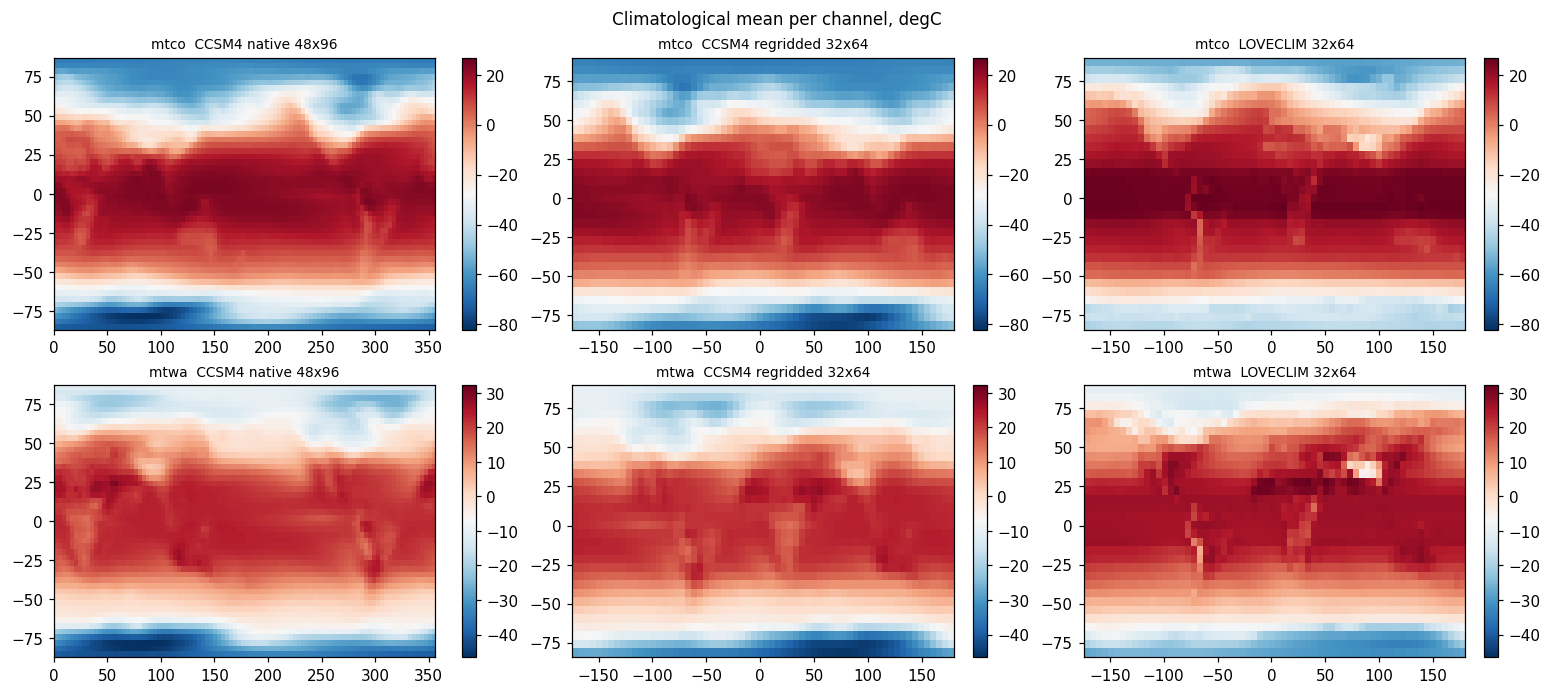

In [6]:
# Geographic registration: the regridded CCSM4 climatology should sit on the same cells
# as the prior's, coastline structure included.
fig, axes = plt.subplots(len(VARS), 3, figsize=(14, 3.1 * len(VARS)), squeeze=False,
                         constrained_layout=True)
panels = [("CCSM4 native 48x96", ccsm_native, run["lat"], run["lon"]),
          ("CCSM4 regridded 32x64", ccsm, lats, lons),
          ("LOVECLIM 32x64", lov, lats, lons)]
for c, name in enumerate(VARS):
    vmin = min(float(f[:, c].mean(0).min()) for _, f, _, _ in panels)
    vmax = max(float(f[:, c].mean(0).max()) for _, f, _, _ in panels)
    for col, (title, field, la, lo) in enumerate(panels):
        ax = axes[c, col]
        im = ax.imshow(field[:, c].mean(0), origin="lower", cmap="RdBu_r",
                       vmin=vmin, vmax=vmax, aspect="auto",
                       extent=[lo[0], lo[-1], la[0], la[-1]])
        ax.set_title(f"{name}  {title}", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Climatological mean per channel, degC", fontsize=11)
fig.savefig(FIG / "alignment_check.png", dpi=110, bbox_inches="tight")
plt.show()

## The two state distributions

Each principal component is a 1-D linear projection of the states, and by the Cramer-Wold
device a distribution is multivariate Gaussian only if every such projection is. So a
visibly non-Gaussian leading component falsifies a Gaussian model of the field
distribution, which is the assumption a 3DVar background covariance rests on.

Three things about how this is set up.

**Anomaly frame.** Each dataset has its own per-cell record mean removed, LOVECLIM over
its 804 states and CCSM4 over its 788 decades. No channel rescaling and no normalisation,
so the projections are in degC and each channel enters with the physical variance it
actually has. Given the asymmetry printed above, CCSM4's components are close to being
`mtco` patterns while LOVECLIM's are genuinely joint.

**Separate bases.** Each dataset is fitted in its own basis, so component *k* is a
different spatial pattern in each column. What the panels compare is the *shape* of a
score distribution, not one quantity measured twice. The table below says how far apart
the two patterns actually are.

**Sign.** An eigenvector is defined only up to sign, so without a convention the two
columns could be mirror images and compare left-to-right rather than shape-to-shape. Each
component is flipped to a positive spatial mean, which makes a positive score a globally
warmer state.

In [7]:
res = {
    f"LOVECLIM ({lov.shape[0]} states)": orient_pcs(pca_scores(lov, N_COMPONENTS)),
    f"CCSM4 210 ppm ({ccsm.shape[0]} decades)": orient_pcs(pca_scores(ccsm, N_COMPONENTS)),
}
for label, r in res.items():
    print(f"{label}")
    print(f"   explained variance {np.round(r['explained_variance_ratio'], 3)}  "
          f"(cumulative {r['explained_variance_ratio'].sum():.3f})")
    print(f"   sign-flipped       {r['flipped']}")

LOVECLIM (804 states)
   explained variance [0.605 0.268 0.038 0.025]  (cumulative 0.936)
   sign-flipped       [False  True False False]
CCSM4 210 ppm (788 decades)
   explained variance [0.858 0.038 0.016 0.01 ]  (cumulative 0.921)
   sign-flipped       [False  True False False]


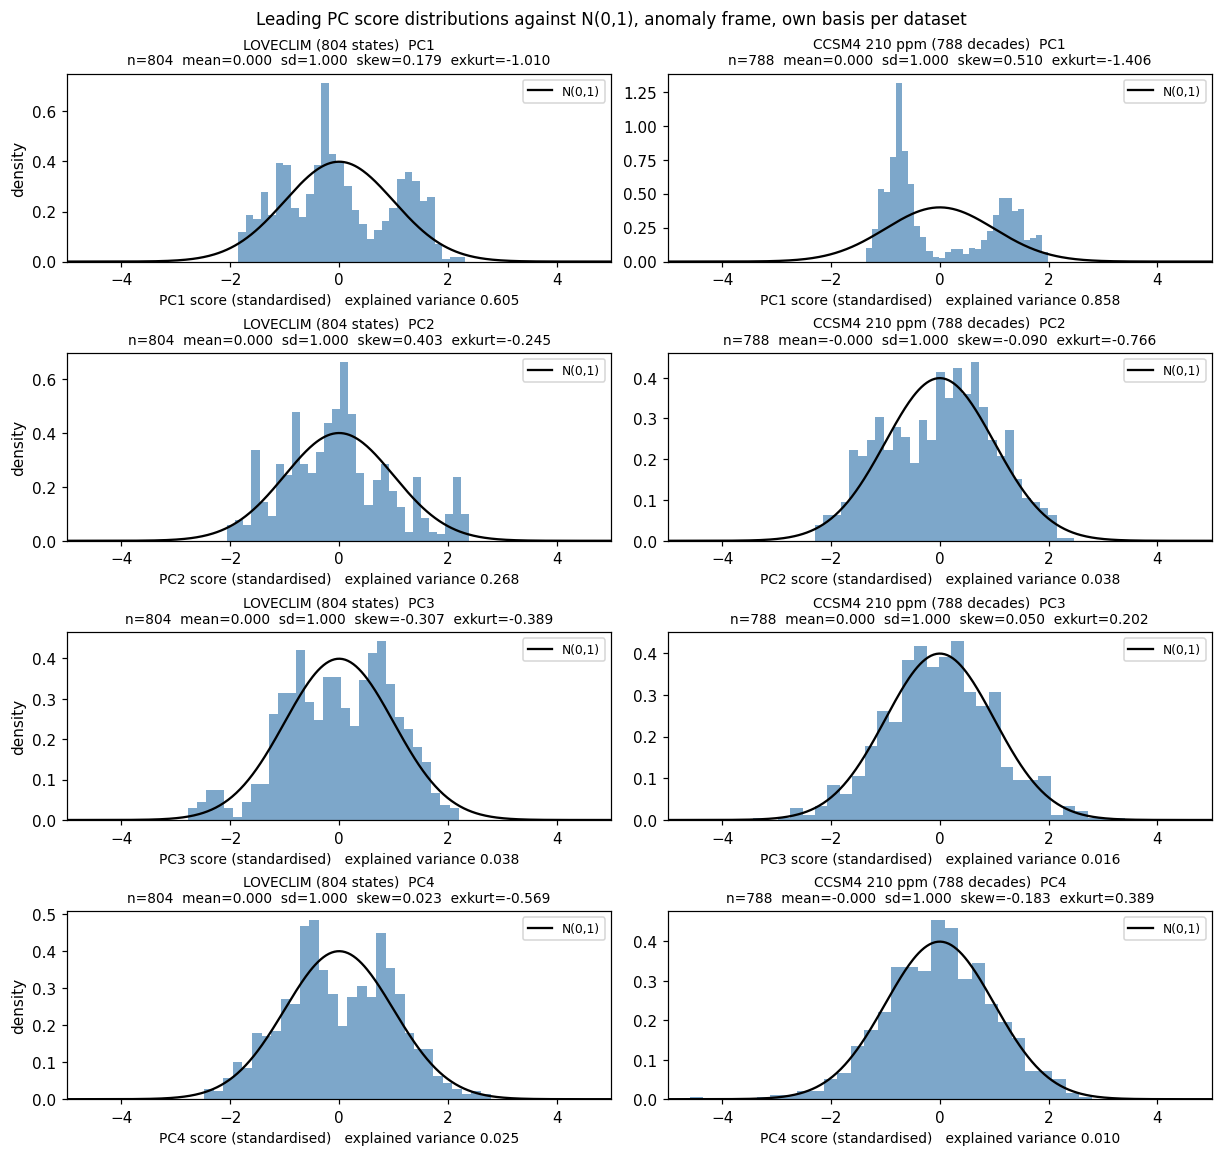

In [8]:
plot_pc_score_distributions(
    res, N_COMPONENTS,
    title="Leading PC score distributions against N(0,1), anomaly frame, own basis per dataset",
    save_path=str(FIG / "pc_score_distributions.png"))
plt.show()

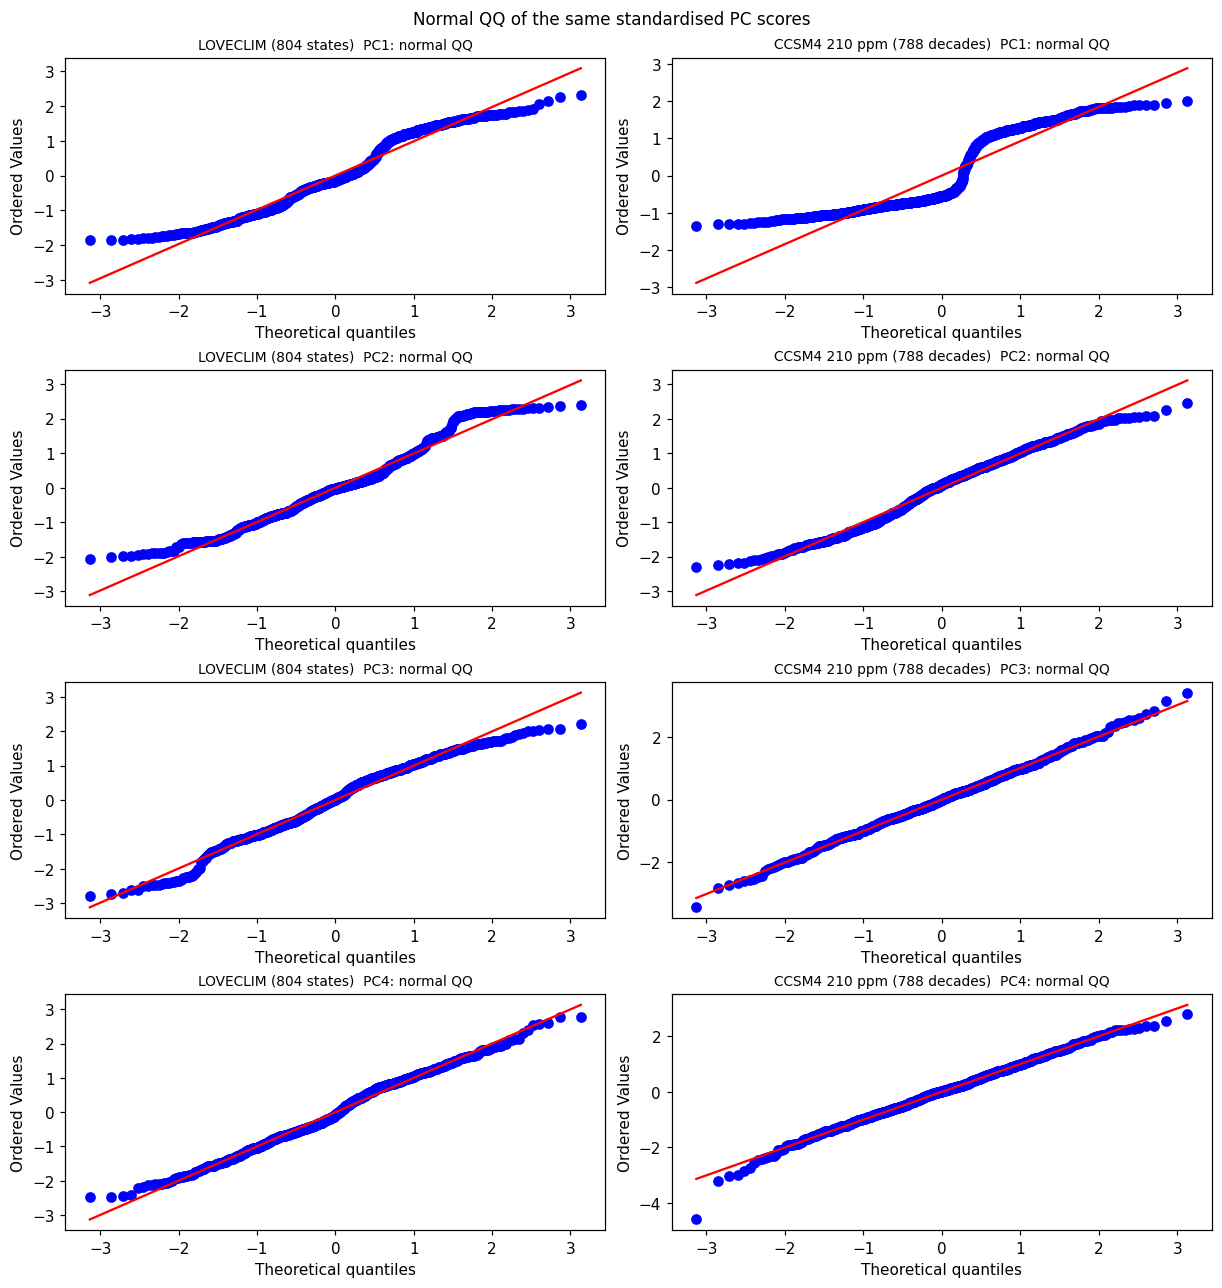

In [9]:
plot_pc_score_qq(
    res, N_COMPONENTS,
    title="Normal QQ of the same standardised PC scores",
    save_path=str(FIG / "pc_score_qq.png"))
plt.show()

### How comparable are the two bases?

Component *k* is fitted separately in each dataset, so "PC2 against PC2" is only a
like-for-like reading when the two spatial patterns resemble each other. The correlation
below says whether they do; both are on the shared 32 x 64 grid, so it is defined.

The mean-loading column is the quantity the sign convention reads. Where it is close to
zero the orientation is set by numerical noise rather than by physics, and the *sign* of
that component's correlation (and of its skew) should not be over-read. The magnitude
still means something.

In [10]:
labels = list(res)
r_pattern = pc_pattern_correlation(res[labels[0]], res[labels[1]], N_COMPONENTS)
table = pd.DataFrame(
    {
        "pattern corr": r_pattern,
        "|pattern corr|": np.abs(r_pattern),
        f"evr {labels[0].split()[0]}": res[labels[0]]["explained_variance_ratio"],
        f"evr {labels[1].split()[0]}": res[labels[1]]["explained_variance_ratio"],
        f"|mean loading| {labels[0].split()[0]}":
            np.abs(res[labels[0]]["components"].reshape(N_COMPONENTS, -1).mean(axis=1)),
        f"|mean loading| {labels[1].split()[0]}":
            np.abs(res[labels[1]]["components"].reshape(N_COMPONENTS, -1).mean(axis=1)),
    },
    index=[f"PC{k + 1}" for k in range(N_COMPONENTS)],
)
display(table.round(4))

,pattern corr,|pattern corr|,evr LOVECLIM,evr CCSM4,|mean loading| LOVECLIM,|mean loading| CCSM4
PC1,0.3302,0.3302,0.6051,0.8576,0.0076,0.0062
PC2,0.3544,0.3544,0.2680,0.0377,0.0046,0.0089
PC3,-0.1729,0.1729,0.0385,0.0161,0.0034,0.0021
PC4,0.0489,0.0489,0.0249,0.0100,0.0042,0.0005


## Control: did the remap change the distribution?

The comparison above uses the regridded cube, because that is the corpus pre-training will
consume. The native 48 x 96 cube is fitted here purely as a control on the remap: if
coarsening 48 x 96 to 32 x 64 had distorted the state distribution, these two columns would
disagree and the headline figure would be reading an artefact rather than the climate.

Only the second column of this figure appears in the comparison above.

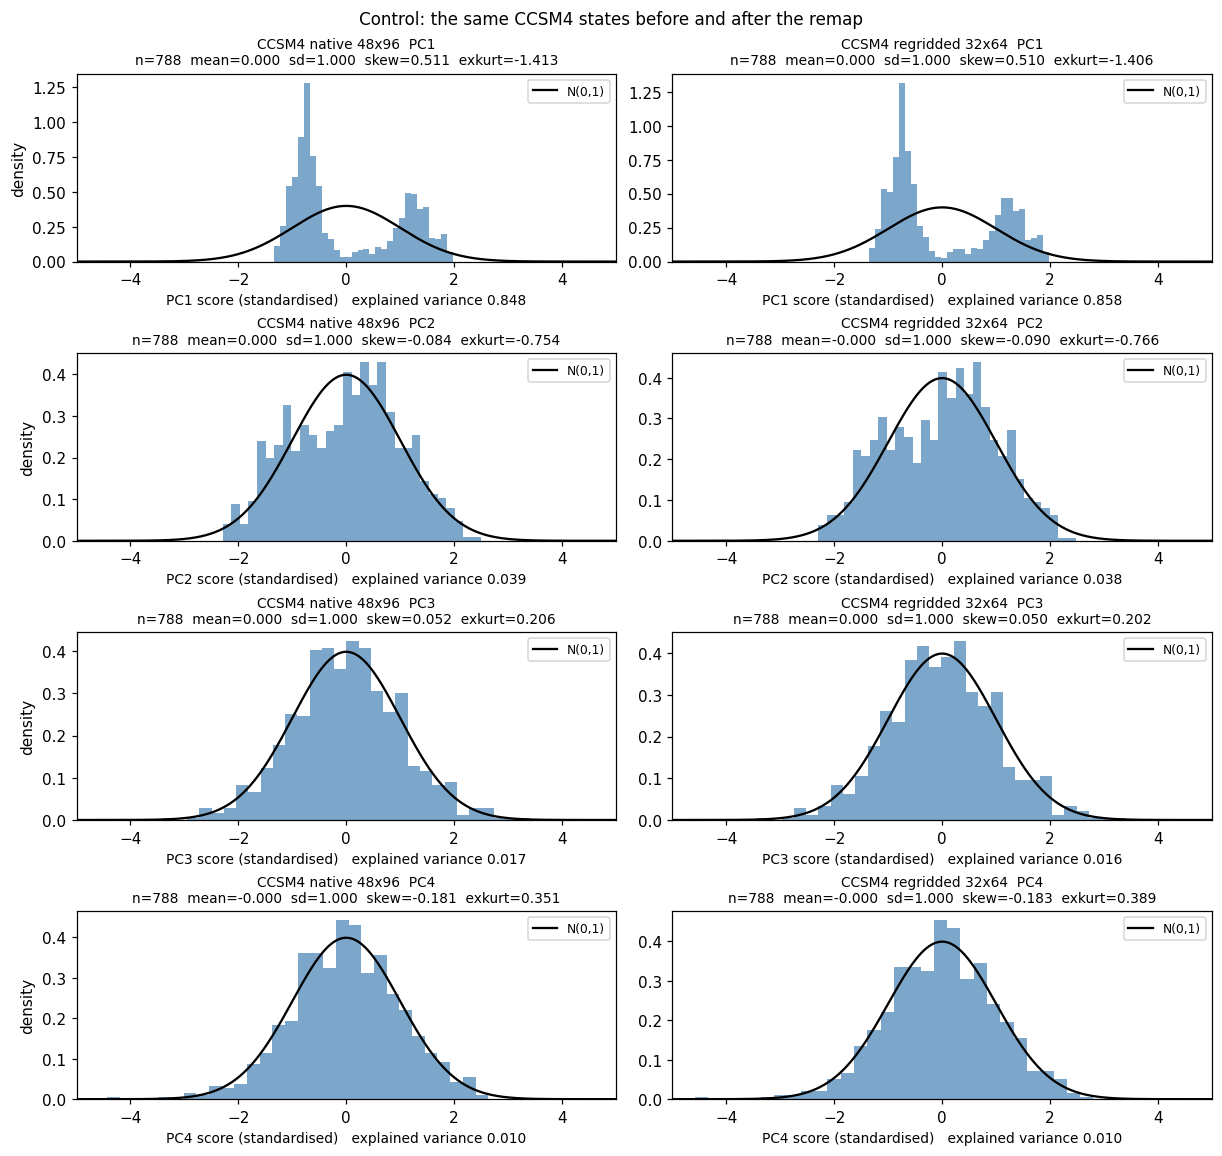

evr                                     skew  \
grid CCSM4 native 48x96 CCSM4 regridded 32x64 CCSM4 native 48x96   
pc                                                                 
PC1              0.8481                0.8576             0.5109   
PC2              0.0390                0.0377            -0.0838   
PC3              0.0168                0.0161             0.0520   
PC4              0.0102                0.0100            -0.1808   

                              excess kurtosis                        
grid CCSM4 regridded 32x64 CCSM4 native 48x96 CCSM4 regridded 32x64  
pc                                                                   
PC1                 0.5102            -1.4129               -1.4057  
PC2                -0.0905            -0.7543               -0.7660  
PC3                 0.0498             0.2062                0.2023  
PC4                -0.1832             0.3506                0.3891

In [11]:
control = {
    f"CCSM4 native {ccsm_native.shape[2]}x{ccsm_native.shape[3]}":
        orient_pcs(pca_scores(ccsm_native, N_COMPONENTS)),
    f"CCSM4 regridded {ccsm.shape[2]}x{ccsm.shape[3]}": res[labels[1]],
}
plot_pc_score_distributions(
    control, N_COMPONENTS,
    title="Control: the same CCSM4 states before and after the remap",
    save_path=str(FIG / "native_vs_regridded.png"))
plt.show()

from scipy import stats

rows = []
for label, r in control.items():
    for k in range(N_COMPONENTS):
        z = r["scores"][:, k] / r["scores"][:, k].std()
        rows.append({"grid": label, "pc": f"PC{k + 1}",
                     "evr": float(r["explained_variance_ratio"][k]),
                     "skew": float(stats.skew(z)),
                     "excess kurtosis": float(stats.kurtosis(z))})
display(pd.DataFrame(rows).pivot(index="pc", columns="grid").round(4))

## Reading

The two figures answer the question this notebook exists to ask: how far apart are the
distributions transfer learning has to bridge.

Read them with three caveats in view.

- **All 788 decades are here, spin-up included.** The equilibration transient after
  branching is non-stationary, so whatever drift it carries sits inside the leading
  component alongside the stadial/interstadial structure. The distribution shown is the
  corpus as it would be used, not a clean stationary sample.
- **The channels are weighted differently in the two datasets.** CCSM4 puts most of its
  joint anomaly variance in `mtco`; LOVECLIM splits it almost evenly. That difference is
  in the data, not in the processing, and it shapes what the leading components are.
- **The two bases are different.** Where the pattern correlation is low, the two columns
  of a row are describing unrelated modes, and only the *shape* of each distribution
  transfers to the comparison.

The alignment itself is now reusable: `paleoreco.data.equilibrium.cube_on_grid` puts any
run of this archive on the prior grid in the prior's own channel definition.